# Pipeline audit — mask labels and loader fidelity

Two checks that sit **upstream of every number in the project**. Neither trains anything;
both are cheap and answer a yes/no question.

**Test 1 — are the ground-truth masks labelled correctly?**
`src/doctamper_dataset.py` collapses the mask with `mask = (mask != 0)`. The DocTamper author's
documented protocol (quoted in our own `src/losses.py`) is three-way:

```
gt[gt < 8]   = 0      # background
gt[gt > 160] = 1      # tampered
gt[gt > 1]   = 100    # uncertain -> ignore_index
```

If the stored masks are clean `{0, 255}` the two rules agree and there is nothing to fix. If they
contain intermediate values, we are training *and evaluating* on wrong labels, our
`ignore_index=100` path is dead code, and every metric shifts.

**Test 2 — how far is our loader from DocTamper's official one?**
Our loader converts to grayscale (`.convert("L")`) and re-encodes every split at a fixed
`JPEG_QUALITY=75`, including the test split. DTD is compression-aware (it consumes the
quantisation table), so this is worth quantifying.

**Calibration:** the released checkpoint scores **0.7799** Pixel-F1 on our TestingSet protocol
against the paper's **0.792**. That 1.2-point gap already says the pipeline is roughly right —
so Test 2 is a *rule-out*, and a large swing in the sweep below would be the surprise, not the
expectation.

Expected runtime after setup: ~15 minutes on a T4.

## 0. Setup

Same CONFIG/setup cells as `final_results_colab.ipynb`, so this notebook drops into the same workflow.

In [1]:
# --- CONFIG (mirrors final_results_colab.ipynb; audit knobs at the bottom) ---
from pathlib import Path

CONFIG = {
    'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
    'PROJECT_BRANCH': 'main',
    'PROJECT_DIR': '/content/HLCV-Project',
    'DOCTAMPER_DIR': '/content/DocTamper',

    'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
    'OUT_ROOT':       '/content/drive/MyDrive/HLCV_samira/pipeline_audit',
    'MANIFEST_DIR':   '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',

    'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
    'CACHE_ZIP_TO_DRIVE': True,
    'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
    'DATA_ROOT': '/content/doctamper_train_test',

    'SEED': 42,
    'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
    'TEST_SOURCE': 'DocTamperV1-TestingSet',
    'TRAIN_SIZE': 800, 'VAL_SIZE': 200, 'TEST_SIZE': 200,

    'BATCH_SIZE': 2, 'JPEG_QUALITY': 75, 'EVAL_THRESHOLD': 0.5,
    'INIT_CHECKPOINT': 'dtd_doctamper.pth',

    # --- audit-specific ---
    'MASK_SCAN_N': 500,                       # masks per split for the histogram
    'MASK_SCAN_SPLITS': ['DocTamperV1-TestingSet', 'DocTamperV1-TrainingSet'],
    'QUALITY_SWEEP': [75, 85, 95],            # re-encode qualities to evaluate
    'PAPER_F1_TESTINGSET': 0.792,             # DTD reported number, our reference point
}
CONFIG

{'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
 'PROJECT_BRANCH': 'main',
 'PROJECT_DIR': '/content/HLCV-Project',
 'DOCTAMPER_DIR': '/content/DocTamper',
 'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
 'OUT_ROOT': '/content/drive/MyDrive/HLCV_samira/pipeline_audit',
 'MANIFEST_DIR': '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',
 'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
 'CACHE_ZIP_TO_DRIVE': True,
 'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
 'DATA_ROOT': '/content/doctamper_train_test',
 'SEED': 42,
 'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
 'TEST_SOURCE': 'DocTamperV1-TestingSet',
 'TRAIN_SIZE': 800,
 'VAL_SIZE': 200,
 'TEST_SIZE': 200,
 'BATCH_SIZE': 2,
 'JPEG_QUALITY': 75,
 'EVAL_THRESHOLD': 0.5,
 'INIT_CHECKPOINT': 'dtd_doctamper.pth',
 'MASK_SCAN_N': 500,
 'MASK_SCAN_SPLITS': ['DocTamperV1-TestingSet', 'DocTamperV1-TrainingSet'],
 'QUALITY_SWEEP': [75, 85, 95],
 'PAPER_F1_TE

In [2]:
# --- Setup: Drive, repos, dependencies ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess
assert Path(CONFIG['CHECKPOINT_DIR']).exists(), (
    f"Not found: {CONFIG['CHECKPOINT_DIR']}\n"
    "In Drive, right-click the shared HLCV folder -> 'Add shortcut to Drive' -> My Drive.")

%cd /content
if not Path(CONFIG['PROJECT_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', '-b', CONFIG['PROJECT_BRANCH'],
                    CONFIG['PROJECT_REPO_URL'], CONFIG['PROJECT_DIR']], check=True)
if not Path(CONFIG['DOCTAMPER_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/qcf-568/DocTamper.git',
                    CONFIG['DOCTAMPER_DIR']], check=True)

!pip -q install lmdb six albumentations timm==0.4.12 segmentation_models_pytorch==0.2.1 kaggle scikit-learn matplotlib
!pip -q install efficientnet_pytorch==0.7.1
!apt-get -qq install -y libjpeg-dev > /dev/null
!pip -q uninstall -y jpegio
!rm -rf /content/jpegio && git clone -q https://github.com/dwgoon/jpegio.git /content/jpegio
%cd /content/jpegio
!pip -q install .
%cd /content/DocTamper/models

sys.path.insert(0, CONFIG['PROJECT_DIR'])
import jpegio
print('jpegio.read:', hasattr(jpegio, 'read'))

Mounted at /content/drive
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 34.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch 0.2.1 requires efficientnet-pytorch==0.6.3, but you have efficientnet-pytorch 0.7.1 which is incompatible.
/content/jpegio
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/content/DocTamper/models
jpegio.read: True


In [3]:
# --- Data: cached zip on Drive -> extract to Colab temp disk ---
import getpass, shutil, subprocess

DATA_ROOT = Path(CONFIG['DATA_ROOT']); DATA_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_ZIP = Path(CONFIG['DRIVE_ZIP'])
need = [DATA_ROOT / CONFIG['TRAIN_SOURCE'] / 'data.mdb', DATA_ROOT / CONFIG['TEST_SOURCE'] / 'data.mdb']

def ensure_kaggle_token():
    if os.environ.get('KAGGLE_API_TOKEN') or os.environ.get('KAGGLE_KEY'):
        return
    kdir = Path.home() / '.kaggle'; kdir.mkdir(parents=True, exist_ok=True)
    if (kdir / 'kaggle.json').exists() or (kdir / 'access_token').exists():
        return
    token = getpass.getpass('Paste Kaggle API token (hidden): ').strip()
    (kdir / 'access_token').write_text(token); (kdir / 'access_token').chmod(0o600)

def get_zip():
    local = Path('/content/doctamper_kaggle/doctamper.zip')
    if local.exists():
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    if DRIVE_ZIP.exists():
        print('using cached zip from Drive'); return DRIVE_ZIP
    print('no cached zip -> downloading from Kaggle')
    ensure_kaggle_token()
    subprocess.run(['kaggle', 'datasets', 'download', '-d', CONFIG['KAGGLE_DATASET'],
                    '-p', str(local.parent)], check=True)
    if CONFIG['CACHE_ZIP_TO_DRIVE']:
        DRIVE_ZIP.parent.mkdir(parents=True, exist_ok=True); shutil.copy2(local, DRIVE_ZIP)
    return local

if not all(p.exists() for p in need):
    zp = get_zip()
    for pat in [f"{CONFIG['TRAIN_SOURCE']}/*", f"{CONFIG['TEST_SOURCE']}/*"]:
        print('extracting', pat)
        subprocess.run(['unzip', '-o', '-q', str(zp), pat, '-d', str(DATA_ROOT)], check=True)
else:
    print('data already on temp disk -> skipping')
for p in need:
    assert p.exists(), f'Missing {p}'
print('data ready:', [p.parent.name for p in need])

using cached zip from Drive
extracting DocTamperV1-TrainingSet/*
extracting DocTamperV1-TestingSet/*
data ready: ['DocTamperV1-TrainingSet', 'DocTamperV1-TestingSet']


In [4]:
# --- Stage checkpoints + qt_table, reuse the seed-42 manifests ---
import shutil, subprocess
%cd /content/DocTamper/models

if not Path('qt_table.pk').exists():
    shutil.copy2(Path(CONFIG['DOCTAMPER_DIR']) / 'qt_table.pk', 'qt_table.pk')
for f in ['vph_imagenet.pt', 'swin_imagenet.pt', CONFIG['INIT_CHECKPOINT']]:
    if not Path(f).exists():
        srcp = Path(CONFIG['CHECKPOINT_DIR']) / f
        assert srcp.exists(), f'Missing {srcp}'
        shutil.copy2(srcp, f); print('staged', f)

MAN = Path(CONFIG['MANIFEST_DIR'])
if not (MAN / 'test.json').exists():
    cmd = [sys.executable, f"{CONFIG['PROJECT_DIR']}/scripts/generate_doctamper_subset.py",
           '--data-root', str(DATA_ROOT), '--output-dir', str(MAN), '--seed', str(CONFIG['SEED']),
           '--train-source', CONFIG['TRAIN_SOURCE'], '--test-source', CONFIG['TEST_SOURCE'],
           '--train-size', str(CONFIG['TRAIN_SIZE']), '--val-size', str(CONFIG['VAL_SIZE']),
           '--test-size', str(CONFIG['TEST_SIZE'])]
    print(subprocess.run(cmd, capture_output=True, text=True).stdout)
assert (MAN / 'test.json').exists(), 'manifest missing'

OUT = Path(CONFIG['OUT_ROOT']); OUT.mkdir(parents=True, exist_ok=True)
print('manifests:', MAN)
print('audit out:', OUT)

/content/DocTamper/models
staged vph_imagenet.pt
staged swin_imagenet.pt
staged dtd_doctamper.pth
manifests: /content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42
audit out: /content/drive/MyDrive/HLCV_samira/pipeline_audit


---
# Test 1 — mask label protocol

## 1a. What is actually stored in the label buffers?

Reads raw label bytes straight from LMDB, records the **container format** (a JPEG container is
the mechanism that would create intermediate values via ringing artefacts) and a full 256-bin
histogram of decoded pixel values.

In [6]:
# --- 1a. Raw mask value histogram, straight from LMDB ---
import numpy as np, cv2, json
from collections import Counter
from src.doctamper_lmdb import open_lmdb, lmdb_keys

def container_format(buf: bytes) -> str:
    if buf[:8] == b'\x89PNG\r\n\x1a\n':      return 'PNG'
    if buf[:3] == b'\xff\xd8\xff':           return 'JPEG'
    if buf[:2] in (b'BM',):                  return 'BMP'
    if buf[:4] in (b'II*\x00', b'MM\x00*'):  return 'TIFF'
    return f'UNKNOWN({buf[:4]!r})'

def scan_masks(split, n):
    """Return (256-bin histogram, format counter, per-image uncertain-pixel counts)."""
    env = open_lmdb(DATA_ROOT / split)
    # Read num-samples from the CACHED env. get_lmdb_num_samples() calls lmdb.open() again on
    # the same path, and LMDB refuses a second open of an environment already open in-process.
    with env.begin(write=False) as txn:
        total = int(txn.get(b'num-samples'))
    idxs = np.linspace(0, total - 1, min(n, total)).astype(int)   # spread across the split
    hist = np.zeros(256, dtype=np.int64)
    fmts, per_image_uncertain = Counter(), []
    for i in idxs:
        _, lk = lmdb_keys(int(i))
        with env.begin(write=False) as txn:
            buf = txn.get(lk.encode('utf-8'))
        if buf is None:
            continue
        fmts[container_format(buf)] += 1
        m = cv2.imdecode(np.frombuffer(buf, dtype=np.uint8), 0)
        if m is None:
            continue
        h = np.bincount(m.ravel(), minlength=256)
        hist += h
        per_image_uncertain.append(int(h[1:161].sum()))
    return hist, fmts, np.array(per_image_uncertain), len(idxs)

SCAN = {}
for split in CONFIG['MASK_SCAN_SPLITS']:
    if not (DATA_ROOT / split / 'data.mdb').exists():
        print(f'skip {split} (not extracted)'); continue
    hist, fmts, unc, n = scan_masks(split, CONFIG['MASK_SCAN_N'])
    SCAN[split] = dict(hist=hist, fmts=fmts, unc=unc, n=n)
    tot = hist.sum()
    print(f'\n=== {split}  (n={n} masks, {tot/1e6:.1f} M pixels) ===')
    print('  container formats :', dict(fmts))
    print(f'  value == 0        : {hist[0]/tot:9.6%}')
    print(f'  value in [1,7]    : {hist[1:8].sum()/tot:9.6%}   <- author rule: background')
    print(f'  value in [8,160]  : {hist[8:161].sum()/tot:9.6%}   <- author rule: IGNORE')
    print(f'  value in [161,255]: {hist[161:].sum()/tot:9.6%}   <- author rule: tampered')
    print(f'  distinct values   : {int((hist > 0).sum())}  -> {np.flatnonzero(hist)[:12].tolist()}...')
    print(f'  images with any pixel in [1,160]: {int((unc > 0).sum())}/{n}')


=== DocTamperV1-TestingSet  (n=500 masks, 131.1 M pixels) ===
  container formats : {'PNG': 500}
  value == 0        : 98.817104%
  value in [1,7]    : 0.475172%   <- author rule: background
  value in [8,160]  : 0.000000%   <- author rule: IGNORE
  value in [161,255]: 0.707725%   <- author rule: tampered
  distinct values   : 3  -> [0, 1, 255]...
  images with any pixel in [1,160]: 124/500

=== DocTamperV1-TrainingSet  (n=500 masks, 131.1 M pixels) ===
  container formats : {'PNG': 500}
  value == 0        : 98.406771%
  value in [1,7]    : 0.229238%   <- author rule: background
  value in [8,160]  : 0.000000%   <- author rule: IGNORE
  value in [161,255]: 1.363991%   <- author rule: tampered
  distinct values   : 3  -> [0, 1, 255]...
  images with any pixel in [1,160]: 55/500


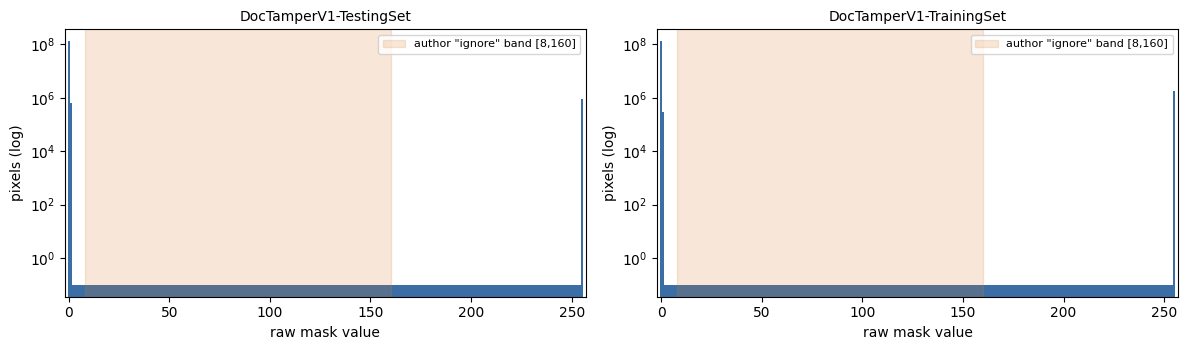

In [7]:
# --- 1a-plot. Log-scale histogram; a clean binary mask shows exactly two spikes ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SCAN), figsize=(6 * len(SCAN), 3.6), squeeze=False)
for ax, (split, d) in zip(axes[0], SCAN.items()):
    ax.bar(np.arange(256), np.maximum(d['hist'], 1e-1), width=1.0, color='#3b6ea5')
    ax.set_yscale('log'); ax.set_xlim(-2, 257)
    ax.axvspan(8, 160, color='#d97b28', alpha=.18, label='author "ignore" band [8,160]')
    ax.set_title(split, fontsize=10); ax.set_xlabel('raw mask value'); ax.set_ylabel('pixels (log)')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / 'test1_mask_histogram.png', dpi=140); plt.show()

## 1b. How many labels would actually change?

The histogram alone does not tell you whether it matters — a handful of stray pixels is noise.
This expresses the disagreement **relative to the number of tampered pixels**, which is the scale
that Pixel-F1 is computed on.

In [8]:
# --- 1b. Disagreement between `!= 0` and the author's three-way rule ---
def author_rule(raw: np.ndarray) -> np.ndarray:
    """raw uint8 -> {0 background, 1 tampered, 100 ignore}."""
    out = np.full(raw.shape, 100, dtype=np.int64)
    out[raw < 8] = 0
    out[raw > 160] = 1
    return out

print(f"{'split':<28}{'tampered(author)':>18}{'ours-extra-FG':>16}{'as % of tampered':>18}{'ignored':>12}")
VERDICT_1 = {}
for split, d in SCAN.items():
    hist = d['hist']
    ignore_band = hist[8:161].sum()
    tampered    = hist[161:].sum()
    ours_extra  = hist[1:161].sum()       # every pixel `!= 0` calls tampered that author does not
    pct = 100.0 * ours_extra / max(tampered, 1)
    VERDICT_1[split] = dict(tampered=int(tampered), extra_fg=int(ours_extra),
                            pct_of_tampered=float(pct), ignored=int(ignore_band))
    print(f'{split:<28}{tampered:>18,}{ours_extra:>16,}{pct:>17.4f}%{ignore_band:>12,}')

worst = max(v['pct_of_tampered'] for v in VERDICT_1.values()) if VERDICT_1 else 0.0
print()
if worst < 0.01:
    print(f'PASS  - masks are effectively binary (worst disagreement {worst:.4f}% of tampered pixels).')
    print('        `mask != 0` is equivalent to the author rule here. No fix needed;')
    print('        the dead ignore_index path is cosmetic. Say this in the report rather than')
    print('        leaving it as an open question.')
elif worst < 1.0:
    print(f'MARGINAL - {worst:.3f}% of tampered pixels are mislabelled. Unlikely to move Pixel-F1')
    print('        meaningfully, but confirm with cell 1c before dismissing it.')
else:
    print(f'FAIL  - {worst:.3f}% of tampered pixels are mislabelled by `mask != 0`.')
    print('        Fix src/doctamper_dataset.py to the three-way rule and re-run the final protocol.')

split                         tampered(author)   ours-extra-FG  as % of tampered     ignored
DocTamperV1-TestingSet                 927,629         622,817          67.1407%           0
DocTamperV1-TrainingSet              1,787,810         300,467          16.8064%           0

FAIL  - 67.141% of tampered pixels are mislabelled by `mask != 0`.
        Fix src/doctamper_dataset.py to the three-way rule and re-run the final protocol.


## 1c. Does it change the metric?

The decisive test: score the released checkpoint on the test manifest under **both** labelling
rules. Under the author rule, `ignore` pixels are excluded from the metric entirely — which is
the part `evaluate()` in the other notebooks cannot currently do, since it does `target.bool()`.

In [9]:
# --- Model + a dataset with switchable label rule / colour / compression ---
import io, tempfile, pickle, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast
from PIL import Image
from sklearn.metrics import roc_auc_score
from src.doctamper_lmdb import load_manifest

_ORIG_LOAD = torch.load
torch.load = lambda *a, **k: _ORIG_LOAD(*a, **{**k, 'weights_only': False})
from dtd import *

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MEAN = np.asarray([0.485, 0.455, 0.406], dtype=np.float32)
STD  = np.asarray([0.229, 0.224, 0.225], dtype=np.float32)

def build_model():
    m = seg_dtd('', 2).to(DEVICE)
    for mod in m.modules():
        if isinstance(mod, nn.GELU) and not hasattr(mod, 'approximate'):
            mod.approximate = 'none'
    sd = torch.load(CONFIG['INIT_CHECKPOINT'], map_location='cpu')['state_dict']
    m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    return m


class AuditDataset(Dataset):
    """ManifestDocTamperDataset with the three audited choices made explicit.

    label_rule : 'nonzero' (current code) | 'author' (three-way with ignore=100)
    color      : 'gray'    (current code, .convert('L')) | 'rgb'
    jpeg       : int quality (current code re-encodes) | 'native' (read DCT from stored bytes)
    """
    def __init__(self, data_root, manifest, qt_table_path, label_rule='nonzero',
                 color='gray', jpeg=75):
        self.manifest = load_manifest(manifest)
        self.samples = list(self.manifest['samples'])
        self.env = open_lmdb(Path(data_root) / str(self.manifest['source_split']))
        self.label_rule, self.color, self.jpeg = label_rule, color, jpeg
        with Path(qt_table_path).open('rb') as f:
            self.qt_tables = pickle.load(f)
        if jpeg != 'native':
            self.qtb = torch.LongTensor(self.qt_tables[int(jpeg)])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, item):
        s = self.samples[item]
        with self.env.begin(write=False) as txn:
            imgbuf = txn.get(s['image_key'].encode('utf-8'))
            lblbuf = txn.get(s['label_key'].encode('utf-8'))

        raw = cv2.imdecode(np.frombuffer(lblbuf, dtype=np.uint8), 0)
        mask = (raw != 0).astype(np.int64) if self.label_rule == 'nonzero' else author_rule(raw)

        src = Image.open(io.BytesIO(imgbuf))
        src = src.convert('L') if self.color == 'gray' else src.convert('RGB')

        if self.jpeg == 'native':
            # Read DCT + quantisation table from the ORIGINAL stored bytes: no second compression.
            with tempfile.NamedTemporaryFile(suffix='.jpg', delete=True) as tmp:
                tmp.write(imgbuf); tmp.flush()
                jpg = jpegio.read(tmp.name)
                dct = jpg.coef_arrays[0].copy()
                qtb = torch.LongTensor(np.asarray(jpg.quant_tables[0]).astype(np.int64))
            rgb_img = Image.open(io.BytesIO(imgbuf)).convert('RGB')
        else:
            with tempfile.NamedTemporaryFile(suffix='.jpg', delete=True) as tmp:
                src.save(tmp.name, 'JPEG', quality=int(self.jpeg))
                jpg = jpegio.read(tmp.name)
                dct = jpg.coef_arrays[0].copy()
                rgb_img = Image.open(tmp.name).convert('RGB')
            qtb = self.qtb.clone()

        arr = (np.asarray(rgb_img).astype(np.float32) / 255.0 - MEAN) / STD
        return {'image': torch.from_numpy(arr.transpose(2, 0, 1)).float(),
                'label': torch.from_numpy(mask).long().unsqueeze(0),
                'rgb': np.clip(np.abs(dct), 0, 20).astype(np.int64),
                'q': qtb, 'sample_id': s['sample_id']}


def forward_dtd(model, batch):
    return model(batch['image'].to(DEVICE), batch['rgb'].to(DEVICE),
                 batch['q'].unsqueeze(1).to(DEVICE))


@torch.no_grad()
def evaluate_audit(model, loader, ignore_index=100, keep_frac=0.05, seed=0):
    """Pixel metrics that EXCLUDE ignore_index pixels (evaluate() in the other notebooks cannot)."""
    model.eval()
    rng = np.random.default_rng(seed)
    tp = fp = fn = 0; probs, labels = [], []
    for batch in loader:
        target = batch['label'].squeeze(1).long().to(DEVICE)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear',
                                       align_corners=False)
        prob = torch.softmax(logits.float(), 1)[:, 1]
        valid = target != ignore_index
        pred, gt = (prob > CONFIG['EVAL_THRESHOLD']) & valid, (target == 1) & valid
        tp += (pred & gt).sum().item()
        fp += (pred & ~gt & valid).sum().item()
        fn += (~pred & gt).sum().item()
        p = prob[valid].flatten().cpu().numpy(); l = gt[valid].flatten().cpu().numpy()
        if len(p):
            k = max(1, int(len(p) * keep_frac))
            idx = rng.choice(len(p), k, replace=False)
            probs.append(p[idx].astype(np.float32)); labels.append(l[idx].astype(np.uint8))
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    y, s = np.concatenate(labels), np.concatenate(probs)
    return {'pixel_f1': 2 * prec * rec / (prec + rec + 1e-9), 'precision': prec, 'recall': rec,
            'iou': tp / (tp + fp + fn + 1e-9),
            'auc': float(roc_auc_score(y, s)) if y.min() != y.max() else float('nan')}


def audit_loader(**kw):
    ds = AuditDataset(DATA_ROOT, MAN / 'test.json', 'qt_table.pk', **kw)
    return DataLoader(ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=0)

print('audit harness ready | device', DEVICE)

audit harness ready | device cuda


/content/DocTamper/models/dtd.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


In [10]:
# --- 1c. Same checkpoint, same images, two labelling rules ---
model = build_model()
T1 = {}
for rule in ['nonzero', 'author']:
    T1[rule] = evaluate_audit(model, audit_loader(label_rule=rule, color='gray',
                                                  jpeg=CONFIG['JPEG_QUALITY']))
    print(f"{rule:<10}", {k: round(v, 4) for k, v in T1[rule].items()})

# Harness sanity check: 'nonzero' + gray + q75 IS the current pipeline, so it must reproduce
# the 0.7799 reported in final_results_colab.ipynb. If it does not, this notebook is measuring
# something other than the real pipeline and nothing below can be trusted.
repro = T1['nonzero']['pixel_f1']
print(f"\nharness check: nonzero/gray/q75 -> {repro:.4f}  (final_results_colab.ipynb: 0.7799)")
assert abs(repro - 0.7799) < 0.01, (
    f'Harness does not reproduce the known pipeline ({repro:.4f} vs 0.7799). '
    'Check the manifest, checkpoint and qt_table before reading any verdict below.')

d = T1['author']['pixel_f1'] - T1['nonzero']['pixel_f1']
print(f"\ndelta Pixel-F1 (author - nonzero) = {d:+.4f}")
print('Reference: the measured seed noise floor in final_ta_design_colab.ipynb is 0.0011 F1.')
print('VERDICT:', 'labelling rule is NOT the issue -- report it as ruled out.' if abs(d) < 0.002
      else 'labelling rule MATTERS -- fix the dataset and re-run every final number.')
del model; torch.cuda.empty_cache()

/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


nonzero    {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}


/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


author     {'pixel_f1': 0.5141, 'precision': 0.4645, 'recall': 0.5757, 'iou': 0.346, 'auc': 0.9181}

harness check: nonzero/gray/q75 -> 0.7799  (final_results_colab.ipynb: 0.7799)

delta Pixel-F1 (author - nonzero) = -0.2658
Reference: the measured seed noise floor in final_ta_design_colab.ipynb is 0.0011 F1.
VERDICT: labelling rule MATTERS -- fix the dataset and re-run every final number.


---
# Test 2 — loader fidelity

## 2a. What does DocTamper's official loader actually do?

Printed, not assumed — so the diff against `src/doctamper_dataset.py` is visible in the notebook
and can go straight into the report.

In [11]:
# --- 2a. Find and print the official dataset class(es) in the cloned DocTamper repo ---
import re, itertools

dt = Path(CONFIG['DOCTAMPER_DIR'])
cands = [p for p in dt.rglob('*.py')
         if re.search(r'class\s+\w*(Dataset|Data)\w*\s*\(', p.read_text(errors='ignore'))]
print('files defining a Dataset class:')
for p in cands:
    print('  ', p.relative_to(dt))

for p in cands:
    txt = p.read_text(errors='ignore').splitlines()
    for i, line in enumerate(txt):
        if re.match(r'\s*class\s+\w*(Dataset|Data)\w*\s*\(', line):
            print(f"\n{'='*78}\n{p.relative_to(dt)}:{i+1}\n{'='*78}")
            print('\n'.join(txt[i:i + 75]))

files defining a Dataset class:
   dataloader.py
   models/eval_dtd.py
   models/tsroie/train.py

dataloader.py:15
class DocTamperDataset(Dataset):
    '''
    A basic dataloader of the inference mode

    roots: path of the LMDB file
    minq : min random compression factor, choiced from (75, 80, 85, 90)
    max_readers : max_readers of the LMDB loader
    '''
    def __init__(self, roots, minq=75, max_nums = None, max_readers=64):
        self.envs = lmdb.open(roots,max_readers=max_readers,readonly=True,lock=False,readahead=False,meminit=False)
        with self.envs.begin(write=False) as txn:
            self.nSamples = int(txn.get('num-samples'.encode('utf-8')))
        if max_nums is None:
            self.max_nums=self.nSamples
        self.max_nums=min(max_nums,self.nSamples)
        self.minq = minq # Q
        with open('qt_table.pk','rb') as fpk:
            pks = pickle.load(fpk)
        self.pks = {}
        for k,v in pks.items():
            self.pks[k] = torch.LongTensor

In [12]:
# --- 2b. Do compression-record pickles exist, and for which splits? ---
pks = sorted(dt.rglob('*.pk')) + sorted(dt.rglob('*.pkl'))
print('pickles in the DocTamper tree:')
for p in pks:
    print(f'  {p.relative_to(dt)}  ({p.stat().st_size/1e6:.2f} MB)')

for split in ['TrainingSet', 'TestingSet', 'FCD', 'SCD']:
    hits = [p.name for p in pks if split.lower() in p.name.lower()]
    print(f'  records for {split:<12}: {hits if hits else "NONE FOUND"}')
print('\nIf TestingSet records exist, the official protocol is reproducible and the fixed')
print('JPEG_QUALITY=75 assumption in our loader can be replaced outright.')

pickles in the DocTamper tree:
  models/qt_table.pk  (0.01 MB)
  pks/DocTamperV1-FCD_75.pk  (0.07 MB)
  pks/DocTamperV1-FCD_80.pk  (0.07 MB)
  pks/DocTamperV1-FCD_85.pk  (0.07 MB)
  pks/DocTamperV1-FCD_90.pk  (0.07 MB)
  pks/DocTamperV1-SCD_75.pk  (0.63 MB)
  pks/DocTamperV1-SCD_80.pk  (0.63 MB)
  pks/DocTamperV1-SCD_85.pk  (0.62 MB)
  pks/DocTamperV1-SCD_90.pk  (0.62 MB)
  pks/DocTamperV1-TestingSet_75.pk  (1.05 MB)
  pks/DocTamperV1-TestingSet_80.pk  (1.04 MB)
  pks/DocTamperV1-TestingSet_85.pk  (1.04 MB)
  pks/DocTamperV1-TestingSet_90.pk  (1.04 MB)
  qt_table.pk  (0.01 MB)
  stg/ocr.pk  (0.00 MB)
  tampering_types/DocTamperV1-FCD.pk  (0.01 MB)
  tampering_types/DocTamperV1-SCD.pk  (0.09 MB)
  tampering_types/DocTamperV1-TestingSet.pk  (0.15 MB)
  tampering_types/DocTamperV1-TrainingSet.pk  (0.71 MB)
  records for TrainingSet : ['DocTamperV1-TrainingSet.pk']
  records for TestingSet  : ['DocTamperV1-TestingSet_75.pk', 'DocTamperV1-TestingSet_80.pk', 'DocTamperV1-TestingSet_85.pk', '

## 2c. Is the stored image already a JPEG — and what is its true quantisation table?

If the LMDB stores JPEG bytes, we can read the **true** DCT coefficients and quantisation table
directly from them, with no second compression and no records pickle. That would make the
`JPEG_QUALITY=75` assumption unnecessary. This cell measures how far the q75 table we currently
feed DTD is from the table the image was actually encoded with.

In [13]:
# --- 2c. Native container, native quantisation table, distance from our q75 assumption ---
env = open_lmdb(DATA_ROOT / CONFIG['TEST_SOURCE'])
man = load_manifest(MAN / 'test.json')
probe = man['samples'][:64]

with open('qt_table.pk', 'rb') as f:
    QT = pickle.load(f)
q75 = np.asarray(QT[75]).astype(np.int64)

fmts, modes, native_qs, rel_err = Counter(), Counter(), [], []
for s in probe:
    with env.begin(write=False) as txn:
        buf = txn.get(s['image_key'].encode('utf-8'))
    fmts[container_format(buf)] += 1
    modes[Image.open(io.BytesIO(buf)).mode] += 1
    if container_format(buf) == 'JPEG':
        with tempfile.NamedTemporaryFile(suffix='.jpg', delete=True) as tmp:
            tmp.write(buf); tmp.flush()
            qt = np.asarray(jpegio.read(tmp.name).quant_tables[0]).astype(np.int64)
        native_qs.append(qt)
        rel_err.append(np.abs(qt - q75).mean() / max(q75.mean(), 1))

print('image container formats:', dict(fmts))
print('PIL image modes        :', dict(modes), '  <- "L" means the source is ALREADY grayscale')
if native_qs:
    nq = np.stack(native_qs)
    print(f'\nnative qtable mean  : {nq.mean():.2f}   (our q75 table mean: {q75.mean():.2f})')
    print(f'identical across images: {bool((nq == nq[0]).all())}')
    print(f'mean |native - q75| / mean(q75) = {np.mean(rel_err):.3f}')
    print('\nnative quant table (first image):'); print(nq[0])
    print('\nour q75 table:'); print(q75)
else:
    print('\nStored images are not JPEG -> "native DCT" is not available; re-encoding is unavoidable.')

image container formats: {'JPEG': 64}
PIL image modes        : {'RGB': 64}   <- "L" means the source is ALREADY grayscale

native qtable mean  : 1.00   (our q75 table mean: 29.03)
identical across images: True
mean |native - q75| / mean(q75) = 0.966

native quant table (first image):
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]]

our q75 table:
[[ 8  6  5  8 12 20 26 31]
 [ 6  6  7 10 13 29 30 28]
 [ 7  7  8 12 20 29 35 28]
 [ 7  9 11 15 26 44 40 31]
 [ 9 11 19 28 34 55 52 39]
 [12 18 28 32 41 52 57 46]
 [25 32 39 44 52 61 60 51]
 [36 46 48 49 56 50 52 50]]


## 2d. Quality sweep — what do the two loader choices actually cost?

Each row is the **same checkpoint on the same 200 test images**; only the loader changes. The
`native` row, if available, is the most faithful pipeline we can build without records pickles.

Reference points: our current pipeline reports **0.7799**, the paper reports **0.792**.

In [14]:
# --- 2d. Sweep: colour handling x compression handling ---
variants = [('gray', CONFIG['JPEG_QUALITY'], 'CURRENT (gray, re-encode q75)')]
variants += [('gray', q, f'gray, re-encode q{q}') for q in CONFIG['QUALITY_SWEEP']
             if q != CONFIG['JPEG_QUALITY']]
variants += [('rgb',  CONFIG['JPEG_QUALITY'], f"rgb,  re-encode q{CONFIG['JPEG_QUALITY']}")]
if fmts.get('JPEG', 0) > 0:
    variants += [('gray', 'native', 'gray, NATIVE dct+qtable'),
                 ('rgb',  'native', 'rgb,  NATIVE dct+qtable')]

model = build_model()
T2 = {}
for color, jpeg, label in variants:
    m = evaluate_audit(model, audit_loader(label_rule='nonzero', color=color, jpeg=jpeg))
    T2[label] = m
    print(f'{label:<34} F1={m["pixel_f1"]:.4f}  P={m["precision"]:.4f}  '
          f'R={m["recall"]:.4f}  IoU={m["iou"]:.4f}  AUC={m["auc"]:.4f}')
del model; torch.cuda.empty_cache()

base = T2['CURRENT (gray, re-encode q75)']['pixel_f1']
best_label = max(T2, key=lambda k: T2[k]['pixel_f1'])
print(f'\nbest variant: {best_label}  F1={T2[best_label]["pixel_f1"]:.4f}  '
      f'(current {base:.4f}, paper {CONFIG["PAPER_F1_TESTINGSET"]:.4f})')

/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


CURRENT (gray, re-encode q75)      F1=0.7799  P=0.8841  R=0.6977  IoU=0.6393  AUC=0.9483


/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


gray, re-encode q85                F1=0.8257  P=0.8980  R=0.7641  IoU=0.7031  AUC=0.9714


/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


...

rgb,  re-encode q75                F1=0.7816  P=0.8825  R=0.7013  IoU=0.6414  AUC=0.9497


/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


gray, NATIVE dct+qtable            F1=0.9601  P=0.9474  R=0.9731  IoU=0.9232  AUC=0.9998


/tmp/ipykernel_842/258507309.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


rgb,  NATIVE dct+qtable            F1=0.9601  P=0.9474  R=0.9731  IoU=0.9232  AUC=0.9998

best variant: gray, NATIVE dct+qtable  F1=0.9601  (current 0.7799, paper 0.7920)


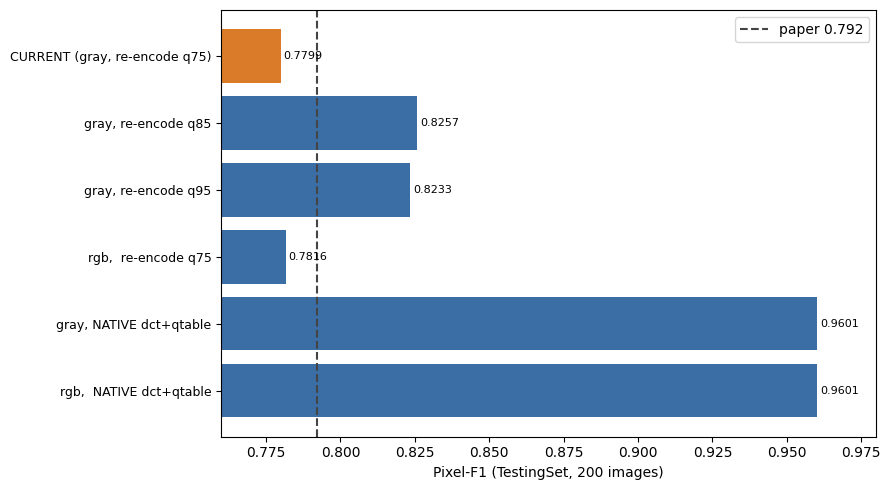

In [15]:
# --- 2d-plot ---
labels = list(T2); vals = [T2[k]['pixel_f1'] for k in labels]
fig, ax = plt.subplots(figsize=(9, 0.5 * len(labels) + 2))
cols = ['#d97b28' if k.startswith('CURRENT') else '#3b6ea5' for k in labels]
ax.barh(range(len(labels)), vals, color=cols)
ax.axvline(CONFIG['PAPER_F1_TESTINGSET'], ls='--', c='#444',
           label=f"paper {CONFIG['PAPER_F1_TESTINGSET']}")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('Pixel-F1 (TestingSet, 200 images)')
ax.set_xlim(min(vals) - 0.02, max(max(vals), CONFIG['PAPER_F1_TESTINGSET']) + 0.02)
for i, v in enumerate(vals):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
ax.legend(); plt.tight_layout()
plt.savefig(OUT / 'test2_loader_sweep.png', dpi=140); plt.show()

---
# Verdict

In [16]:
# --- Summary: what to do next, written to Drive ---
spread = max(v['pixel_f1'] for v in T2.values()) - min(v['pixel_f1'] for v in T2.values())
label_delta = T1['author']['pixel_f1'] - T1['nonzero']['pixel_f1']
NOISE = 0.0011                      # measured seed std, final_ta_design_colab.ipynb

lines = ['# Pipeline audit — verdict', '',
         '## Test 1: mask label protocol', '']
for split, v in VERDICT_1.items():
    lines.append(f"- `{split}`: {v['pct_of_tampered']:.4f}% of tampered pixels disagree "
                 f"between `!= 0` and the author rule ({v['ignored']:,} px in the ignore band)")
lines += ['', f'- Pixel-F1 under author rule minus `!= 0` rule: **{label_delta:+.4f}** '
              f'(noise floor {NOISE})',
          '', f"**{'RULED OUT' if abs(label_delta) < 2*NOISE else 'ACTION REQUIRED'}** — "
              + ('the labelling rule does not move the metric; report it as checked.'
                 if abs(label_delta) < 2 * NOISE else
                 'fix `src/doctamper_dataset.py` to the three-way rule, then re-run '
                 'the final protocol, the loss ablation and the seed study.'),
          '', '## Test 2: loader fidelity', '',
          '| loader variant | Pixel-F1 | precision | recall | IoU | AUC |', '|---|---|---|---|---|---|']
for k, v in T2.items():
    lines.append(f"| {k} | {v['pixel_f1']:.4f} | {v['precision']:.4f} | {v['recall']:.4f} | "
                 f"{v['iou']:.4f} | {v['auc']:.4f} |")
lines += ['', f'- Spread across loader variants: **{spread:.4f}** F1 (noise floor {NOISE})',
          f"- Paper reference on TestingSet: {CONFIG['PAPER_F1_TESTINGSET']}",
          '', f"**{'RULED OUT' if spread < 0.01 else 'ACTION REQUIRED'}** — "
              + ('grayscale conversion and the fixed q75 assumption cost little; the current '
                 'loader is defensible and should simply be stated as a documented deviation.'
                 if spread < 0.01 else
                 'the loader choices move the metric more than the effect we are trying to '
                 'measure. Switch to the best variant above and re-run the final numbers.')]

txt = '\n'.join(lines)
(OUT / 'verdict.md').write_text(txt)
with (OUT / 'verdict.json').open('w') as fh:
    json.dump({'test1': dict(VERDICT_1), 'test1_metrics': T1, 'test2_metrics': T2,
               'label_delta': label_delta, 'loader_spread': spread}, fh, indent=2, default=float)
print(txt)
print('\nsaved ->', OUT)

# Pipeline audit — verdict

## Test 1: mask label protocol

- `DocTamperV1-TestingSet`: 67.1407% of tampered pixels disagree between `!= 0` and the author rule (0 px in the ignore band)
- `DocTamperV1-TrainingSet`: 16.8064% of tampered pixels disagree between `!= 0` and the author rule (0 px in the ignore band)

- Pixel-F1 under author rule minus `!= 0` rule: **-0.2658** (noise floor 0.0011)

**ACTION REQUIRED** — fix `src/doctamper_dataset.py` to the three-way rule, then re-run the final protocol, the loss ablation and the seed study.

## Test 2: loader fidelity

| loader variant | Pixel-F1 | precision | recall | IoU | AUC |
|---|---|---|---|---|---|
| CURRENT (gray, re-encode q75) | 0.7799 | 0.8841 | 0.6977 | 0.6393 | 0.9483 |
| gray, re-encode q85 | 0.8257 | 0.8980 | 0.7641 | 0.7031 | 0.9714 |
| gray, re-encode q95 | 0.8233 | 0.9337 | 0.7363 | 0.6997 | 0.9558 |
| rgb,  re-encode q75 | 0.7816 | 0.8825 | 0.7013 | 0.6414 | 0.9497 |
| gray, NATIVE dct+qtable | 0.9601 | 0.9474 | 0.9731 |